In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df.shape

(150, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


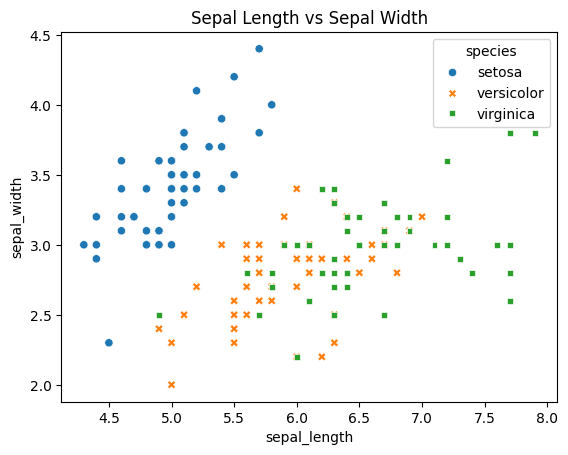

In [10]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species',
                data = df,style='species')
plt.title('Sepal Length vs Sepal Width')
plt.show()

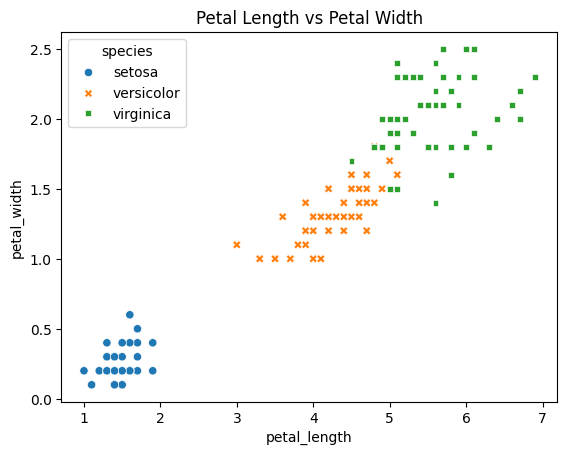

In [11]:
sns.scatterplot(data=df, x= 'petal_length',
                y='petal_width', hue='species', style='species')
plt.title('Petal Length vs Petal Width')
plt.show()

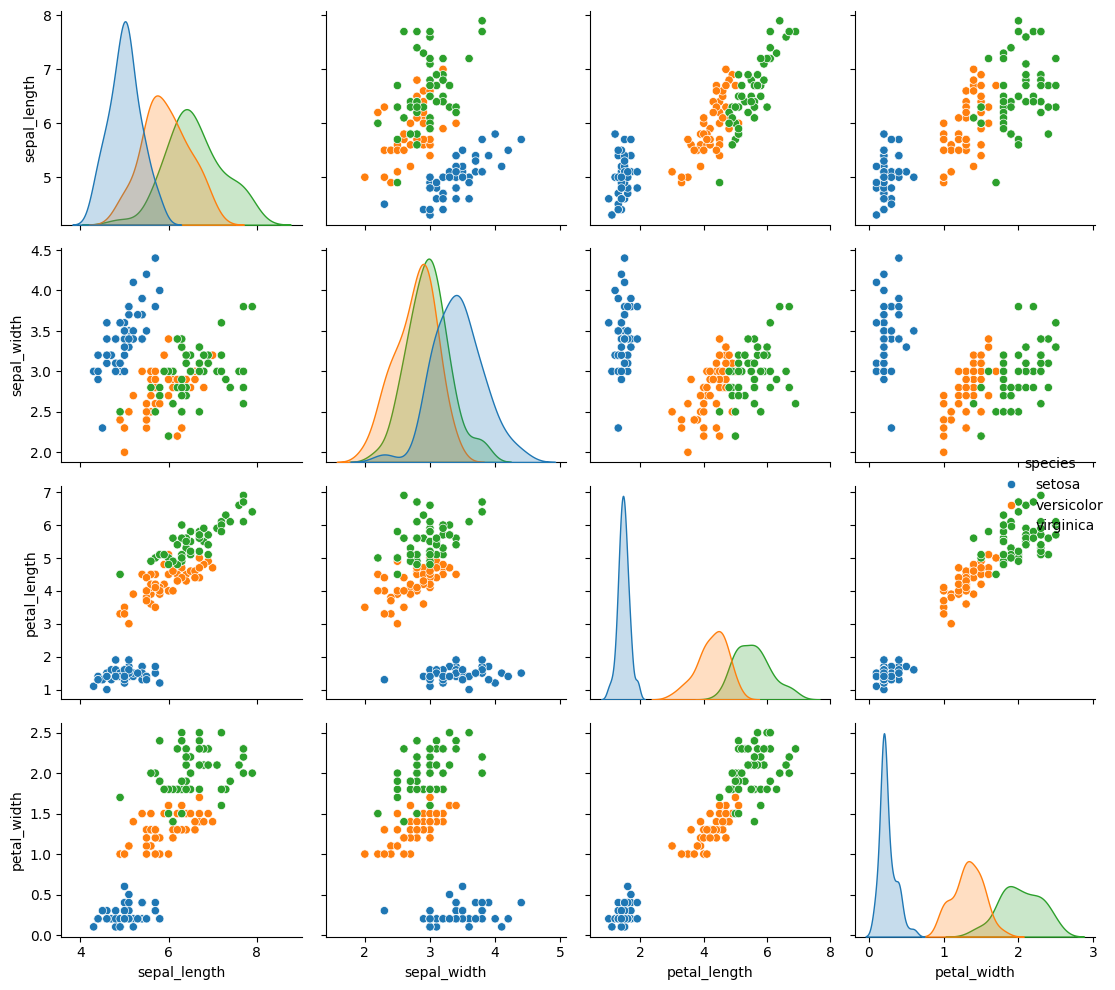

In [13]:
sns.pairplot(df, hue='species', diag_kind='kde')
plt.tight_layout()
plt.show()

In [14]:
X = df.drop('species', axis = 1)
y = df['species']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
X_train.shape, X_test.shape

((120, 4), (30, 4))

In [15]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(species
 virginica     0.333333
 setosa        0.333333
 versicolor    0.333333
 Name: proportion, dtype: float64,
 species
 virginica     0.333333
 setosa        0.333333
 versicolor    0.333333
 Name: proportion, dtype: float64)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=7)
model.fit(X_train_scaled, y_train)
y_prob = model.predict_proba(X_test_scaled)
y_prob[:5]

array([[2.08855905e-03, 3.96597626e-01, 6.01313815e-01],
       [9.71872728e-01, 2.81266075e-02, 6.64225809e-07],
       [9.88743602e-01, 1.12561813e-02, 2.16702097e-07],
       [1.51656053e-02, 7.58203940e-01, 2.26630455e-01],
       [5.81618709e-04, 1.88204959e-01, 8.11213422e-01]])

In [18]:
ypred = model.predict(X_test_scaled)
ypred

array(['virginica', 'setosa', 'setosa', 'versicolor', 'virginica',
       'versicolor', 'virginica', 'setosa', 'virginica', 'virginica',
       'versicolor', 'setosa', 'setosa', 'versicolor', 'versicolor',
       'versicolor', 'setosa', 'setosa', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'versicolor', 'setosa', 'virginica',
       'virginica', 'virginica', 'versicolor', 'setosa', 'virginica'],
      dtype=object)

In [20]:
y_test.values

array(['virginica', 'setosa', 'setosa', 'versicolor', 'virginica',
       'versicolor', 'virginica', 'setosa', 'virginica', 'virginica',
       'versicolor', 'setosa', 'setosa', 'versicolor', 'versicolor',
       'versicolor', 'setosa', 'setosa', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'versicolor', 'setosa', 'virginica',
       'virginica', 'virginica', 'versicolor', 'setosa', 'virginica'],
      dtype=object)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
print(classification_report(y_test, ypred))
print(confusion_matrix(y_test, ypred))
print(accuracy_score(y_test, ypred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
1.0


In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report



In [3]:
def build_loan_default_tree():
    # Step 1: Generate synthetic dataset
    np.random.seed(42)
    n_samples = 500
    features = {
        'income': np.random.uniform(20000, 150000, n_samples),
        'age': np.random.randint(18, 70, n_samples),
        'loan_amount': np.random.uniform(1000, 50000, n_samples),
        'credit_score': np.random.randint(300, 850, n_samples),
        'employment_years': np.random.randint(0, 40, n_samples)
    }
    df = pd.DataFrame(features)
    # Step 2: Create binary target
    df['default'] = np.where(
        (df['credit_score'] < 500) & (df['loan_amount'] > 15000), 1, 0
    )
    X = df.drop('default', axis = 1)
    y = df['default']
    # Step 3: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Step 4: Train DecisionTreeClassifier
    dt = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                random_state=42)
    dt.fit(X_train, y_train)
    # Step 5: Predict and print classification report
    y_pred = dt.predict(X_test)
    y_prob = dt.predict_proba(X_test)[:, 1]
    print("Classification Report:\n",classification_report(y_test, y_pred))
    # Step 6: Extract and print top feature by importance
    imps = dt.feature_importances_
    top_idx = np.argmax(imps)
    top_name = X.columns[top_idx]
    print(f"Top feature: {top_name} with importance {imps[top_idx]:.4f}")
    # Step 7: Report whether any class recall < 0.60
    recall0 = classification_report(y_test, y_pred, output_dict=True)['0']['recall']
    recall1 = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    if recall0 < 0.60 or recall1 < 0.60:
        recall_bel = "Yes"
    else:
        recall_bel = "No"
    print(f"Any class recall < 0.60? {recall_bel}")

if __name__ == "__main__":
    build_loan_default_tree()


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Top feature: credit_score with importance 0.5693
Any class recall < 0.60? No
